In [ ]:
!pip3 install tslearn

## Imports

In [ ]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, TimeSeriesScalerMeanVariance
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from tslearn.clustering import TimeSeriesKMeans
from sklearn.decomposition import PCA
from scipy.stats import chi2_contingency
from sklearn.manifold import TSNE

## Datasets Loading

In [4]:
df_paa = pd.read_csv("../3/data/ecg_paa.csv")

In [13]:
df_features = pd.read_csv("../3/data/ecg_features.csv")

In [38]:
labels_df = pd.read_csv("../4/data/patient_profiles_with_labels.csv")

In [ ]:
paa_features = df_paa.drop(columns=['subject_id', 'hadm_id'])
scaler = StandardScaler()
paa_scaled = scaler.fit_transform(paa_features)

## METHOD 1 — K-Means on PAA

### Elbow plot

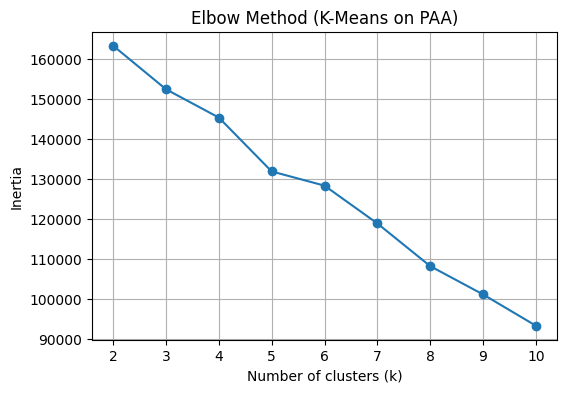

In [21]:
inertia = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(paa_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method (K-Means on PAA)")
plt.grid(True)
plt.show()

### Silhouette plot

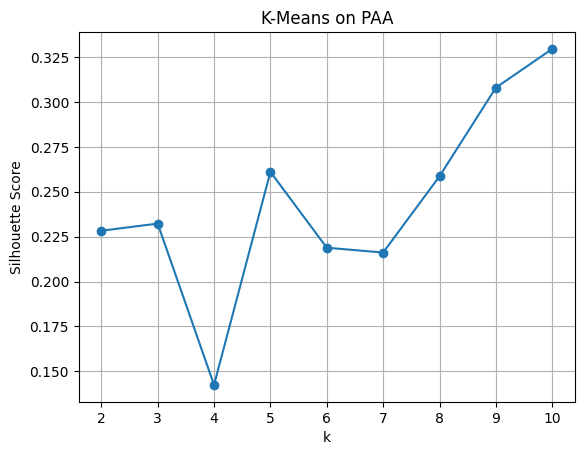

In [8]:
sil_scores = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(paa_scaled)
    sil_scores.append(silhouette_score(paa_scaled, labels))

plt.plot(K, sil_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("K-Means on PAA")
plt.grid(True)
plt.show()

5 seems to be the best K

In [23]:
k_opt = 5
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=20)
df_paa['cluster_kmeans'] = kmeans.fit_predict(paa_scaled)

In [24]:
df_paa.groupby('cluster_kmeans').mean().T

cluster_kmeans,0,1,2,3,4
subject_id,1.447663e+07,1.469132e+07,1.510062e+07,1.402899e+07,1.474000e+07
hadm_id,4.492144e+07,4.507136e+07,4.484551e+07,4.532100e+07,4.500669e+07
paa_0,1.662625e-02,5.202589e-01,-2.566127e-01,5.436026e-01,-4.175224e-01
paa_1,5.764283e-02,3.361540e-01,1.055117e+00,2.488549e-01,-4.342341e-01
paa_2,3.690710e-02,-2.527777e-02,-7.416366e-02,-6.837854e-01,-3.474944e-01
...,...,...,...,...,...
paa_97,1.999456e-01,-4.464280e-02,-8.534886e-01,-1.086540e+00,1.561424e+00
paa_98,-5.080989e-02,-6.934126e-01,4.149084e-01,-7.745669e-01,2.741252e+00
paa_99,8.259114e-02,-1.038334e+00,4.629584e-02,5.225541e-01,3.217640e+00
cluster_dtw,9.593103e-01,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00


## What do clusters look like?
### Plot average PAA per cluster

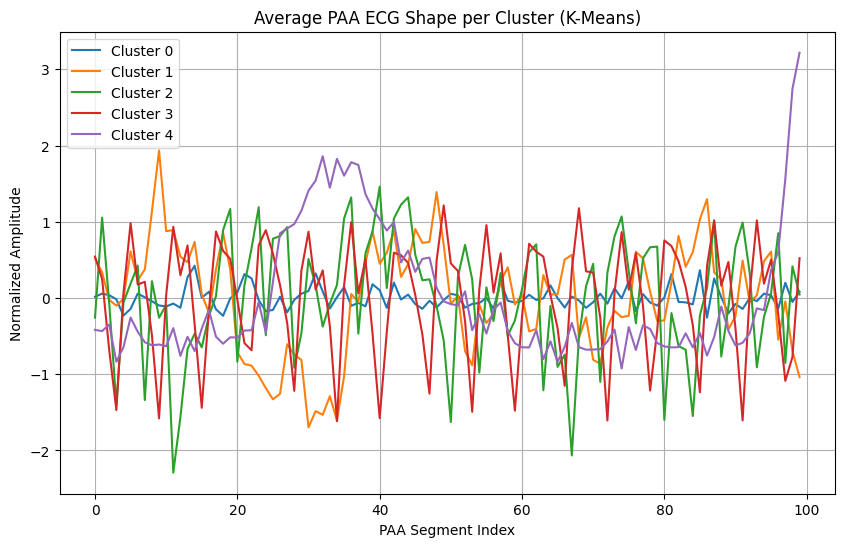

In [25]:
df_paa['cluster'] = kmeans.labels_

plt.figure(figsize=(10,6))

for c in sorted(df_paa['cluster'].unique()):
    cluster_data = df_paa[df_paa['cluster'] == c]
    mean_paa = cluster_data.filter(like='paa_').mean()
    plt.plot(mean_paa.values, label=f'Cluster {c}')

plt.title("Average PAA ECG Shape per Cluster (K-Means)")
plt.xlabel("PAA Segment Index")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.grid(True)
plt.show()

## PCA visualization

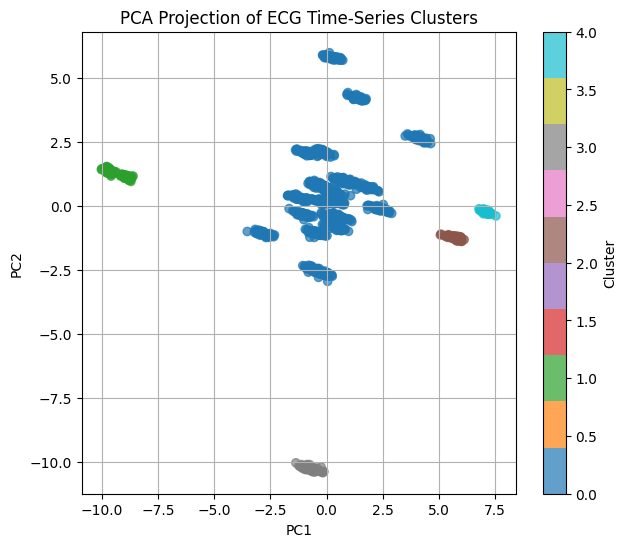

In [31]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(paa_scaled)

plt.figure(figsize=(7,6))
scatter = plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=df_paa['cluster'],
    cmap='tab10',
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of ECG Time-Series Clusters")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

## t-SNE visualization

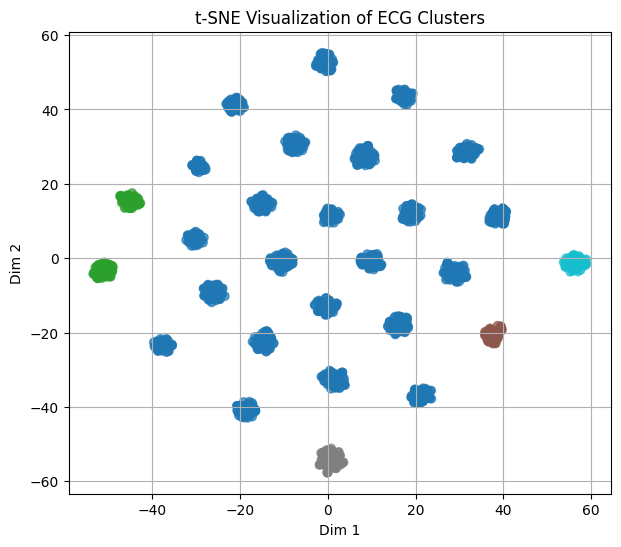

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(paa_scaled)

plt.figure(figsize=(7,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1],
            c=df_paa['cluster'],
            cmap='tab10',
            alpha=0.7)
plt.title("t-SNE Visualization of ECG Clusters")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.show()

## Explaining clusters using SIMPLE SCALAR FEATURES

In [33]:
df_cluster_features = df_features.merge(
    df_paa[['subject_id', 'cluster']],
    on='subject_id'
)

cluster_summary = df_cluster_features.groupby('cluster').mean()
cluster_summary[['mean_hr', 'std_hr', 'energy', 'rmssd', 'dominant_freq']]

,mean_hr,std_hr,energy,rmssd,dominant_freq
cluster,,,,,
0,69.245634,7.961496,4999.0,0.157126,2.663517
1,64.180570,5.985716,4999.0,0.129736,0.296825
2,65.612181,15.944796,4999.0,0.365130,2.300000
3,91.151338,8.271591,4999.0,0.142208,1.600000
4,58.227302,1.379771,4999.0,0.029872,0.197059


### Bar plots

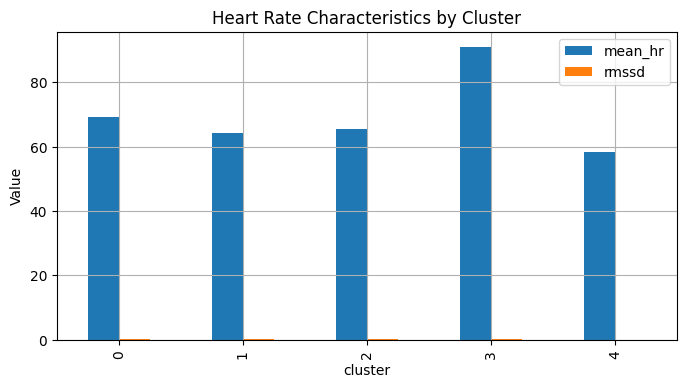

In [34]:
cluster_summary[['mean_hr', 'rmssd']].plot(
    kind='bar', figsize=(8,4)
)
plt.title("Heart Rate Characteristics by Cluster")
plt.ylabel("Value")
plt.grid(True)
plt.show()

## Radar (Spider) plots per cluster

### Normalizing features first

In [ ]:
features_to_plot = ['mean_hr', 'rmssd', 'energy', 'std', 'dominant_freq']
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(cluster_summary[features_to_plot])

radar_df = pd.DataFrame(
    scaled_features,
    index=cluster_summary.index,
    columns=features_to_plot
)

### Radar plot

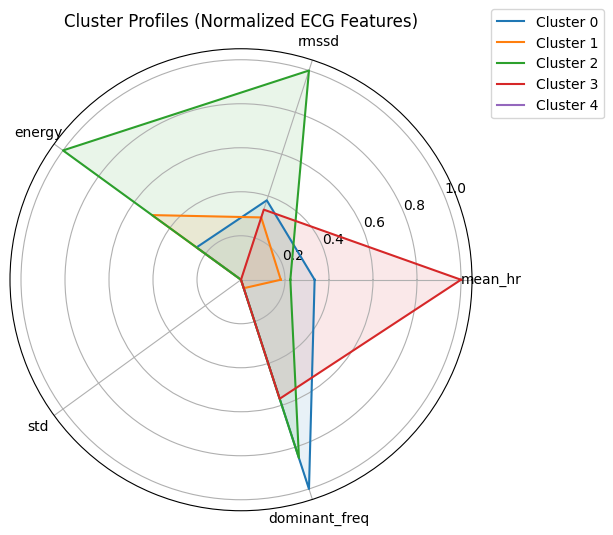

In [ ]:
angles = np.linspace(0, 2*np.pi, len(features_to_plot), endpoint=False)
angles = np.concatenate([angles, [angles[0]]])

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

for idx, row in radar_df.iterrows():
    values = row.values
    values = np.concatenate([values, [values[0]]])
    ax.plot(angles, values, label=f'Cluster {idx}')
    ax.fill(angles, values, alpha=0.1)

ax.set_thetagrids(angles[:-1] * 180/np.pi, features_to_plot)
ax.set_title("Cluster Profiles (Normalized ECG Features)")
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

## Representative ECG for each cluster

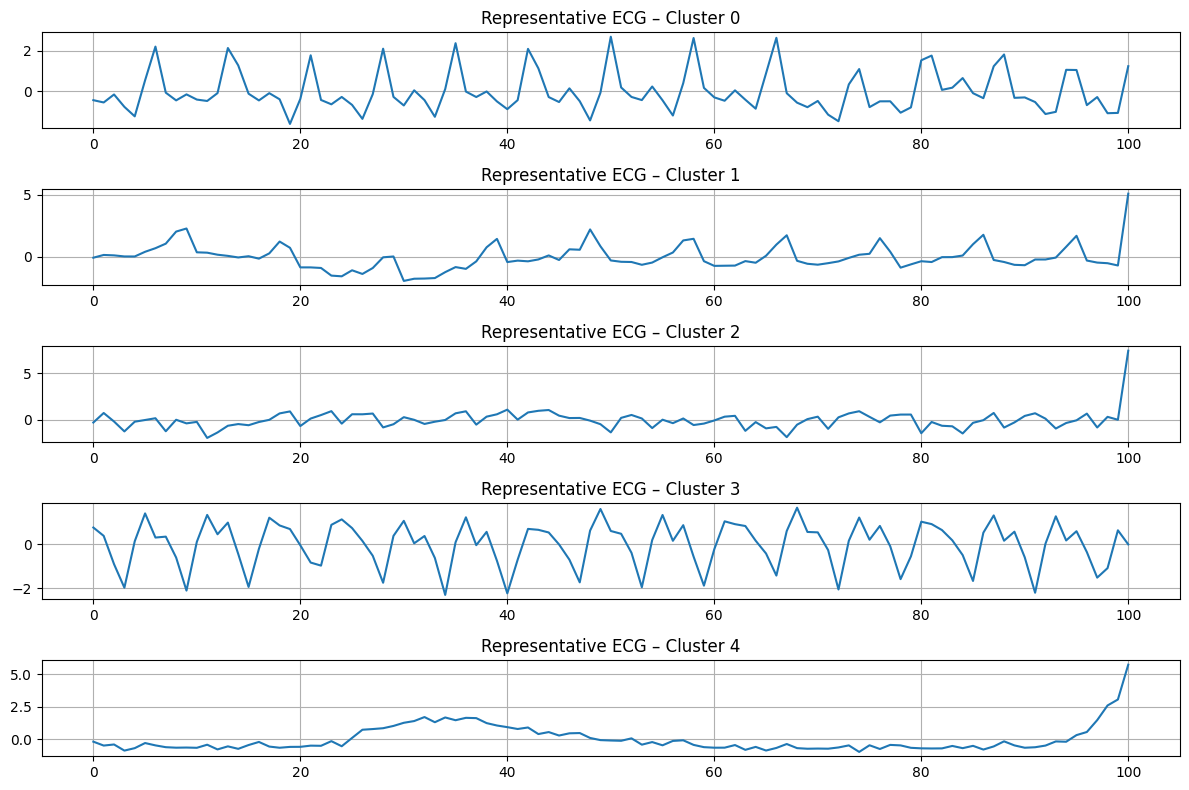

In [ ]:
plt.figure(figsize=(12,8))

for i, c in enumerate(sorted(df_paa['cluster'].unique())):
    cluster_ids = df_paa[df_paa['cluster'] == c].index
    idx = random.choice(cluster_ids)

    ts = X_ts[idx].ravel()
    plt.subplot(len(df_paa['cluster'].unique()), 1, i+1)
    plt.plot(ts)
    plt.title(f"Representative ECG - Cluster {c}")
    plt.grid(True)

plt.tight_layout()
plt.show()

## Relation of clusters to CLINICAL LABELS

In [41]:
df_eval = df_paa.merge(labels_df, on='subject_id')

pd.crosstab(df_eval['cluster'], df_eval['ischemic_disease'], normalize='index')

ischemic_disease,0,1
cluster,,
0,0.516854,0.483146
1,0.481481,0.518519
2,0.589744,0.410256
3,0.577778,0.422222
4,0.375000,0.625000


### Distribution of Ischemic vs Non-Ischemic Patients per Cluster

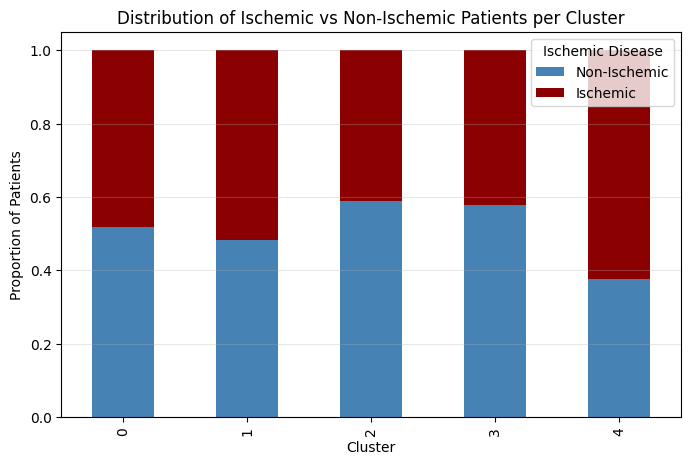

In [ ]:
ct = pd.crosstab(df_eval['cluster'], df_eval['ischemic_disease'], normalize='index')

ct.plot(kind='bar', stacked=True, figsize=(8,5),
        color=['steelblue', 'darkred'])

plt.title("Distribution of Ischemic vs Non-Ischemic Patients per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Proportion of Patients")
plt.legend(title="Ischemic Disease", labels=["Non-Ischemic", "Ischemic"])
plt.grid(axis='y', alpha=0.3)
plt.show()

### p-values & chi-square test

In [ ]:
counts = pd.crosstab(df_eval['cluster'], df_eval['ischemic_disease'])
chi2, p, dof, expected = chi2_contingency(counts)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p:.4f}")

Chi-square statistic: 5.10
p-value: 0.2775


## Are clusters meaningful or random?
### Cluster size distribution

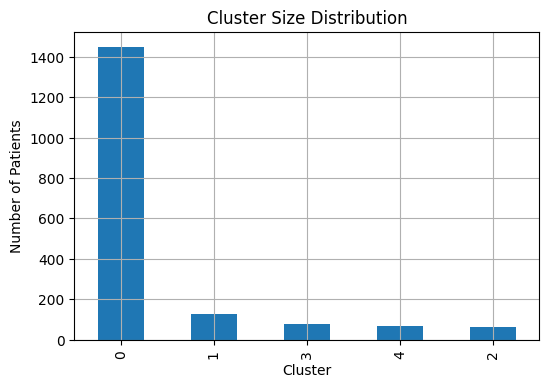

In [27]:
df_paa['cluster'].value_counts().plot(
    kind='bar', figsize=(6,4), title="Cluster Size Distribution"
)
plt.xlabel("Cluster")
plt.ylabel("Number of Patients")
plt.grid(True)
plt.show()

## METHOD 2 — DTW Clustering

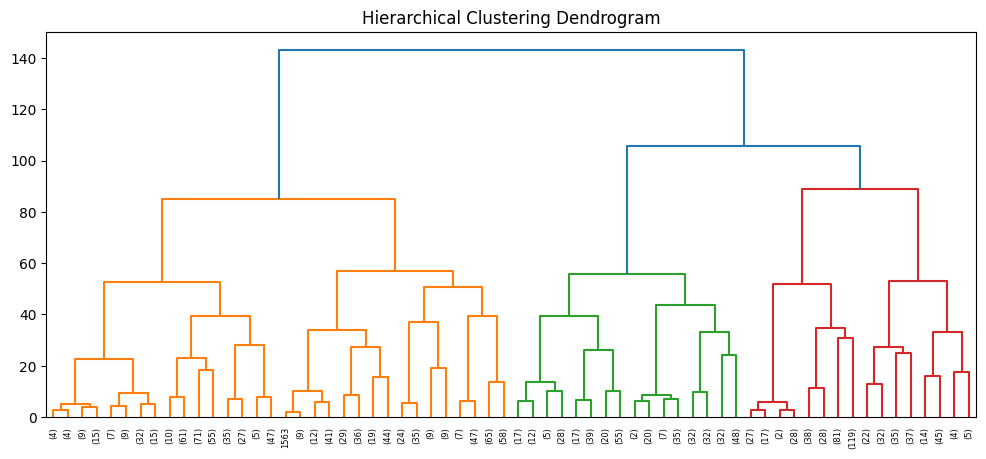

In [26]:
X_feat = df_features.drop(columns=['subject_id', 'hadm_id'])
X_feat_scaled = StandardScaler().fit_transform(X_feat)

Z = linkage(X_feat_scaled, method='ward')

plt.figure(figsize=(12,5))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

In [17]:
df_features['cluster_hier'] = fcluster(Z, t=4, criterion='maxclust')

In [20]:
X_ts = df_paa.drop(columns=['subject_id', 'hadm_id']).values
X_ts = X_ts[:, :, np.newaxis]

X_ts = TimeSeriesScalerMeanVariance().fit_transform(X_ts)

dtw_km = TimeSeriesKMeans(
    n_clusters=3,
    metric="dtw",
    random_state=42
)
df_paa['cluster_dtw'] = dtw_km.fit_predict(X_ts)

### Plot average time series per DTW cluster

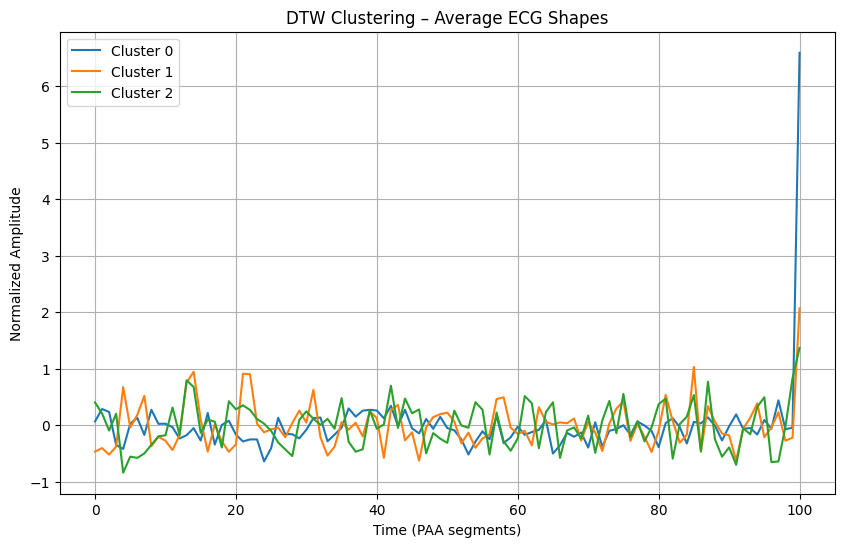

In [28]:
plt.figure(figsize=(10,6))

for c in np.unique(df_paa['cluster_dtw']):
    idx = df_paa['cluster_dtw'] == c
    mean_ts = X_ts[idx].mean(axis=0).ravel()
    plt.plot(mean_ts, label=f'Cluster {c}')

plt.title("DTW Clustering – Average ECG Shapes")
plt.xlabel("Time (PAA segments)")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.grid(True)
plt.show()

## Compare K-Means vs DTW

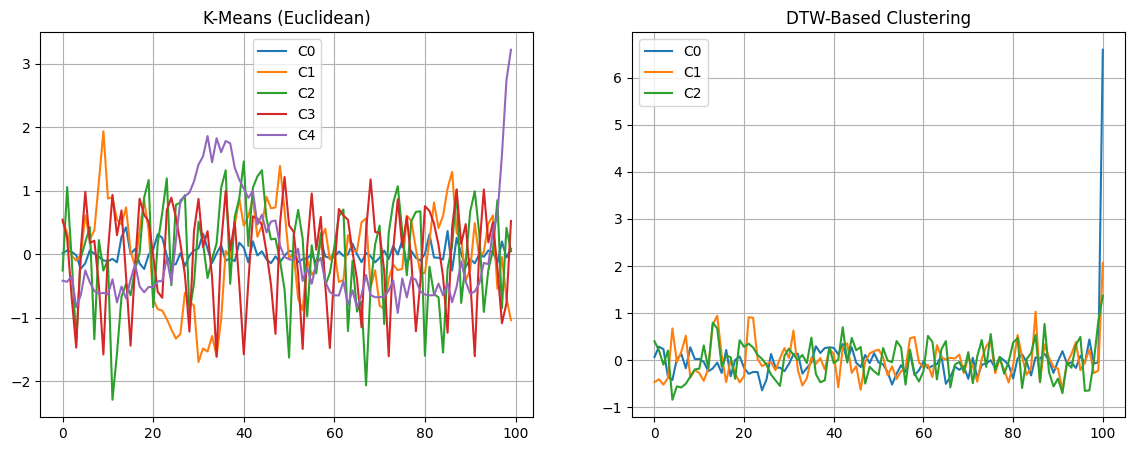

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# K-Means
for c in sorted(df_paa['cluster'].unique()):
    axes[0].plot(
        df_paa[df_paa['cluster'] == c].filter(like='paa_').mean().values,
        label=f'C{c}'
    )
axes[0].set_title("K-Means (Euclidean)")
axes[0].legend()
axes[0].grid(True)

# DTW
for c in np.unique(df_paa['cluster_dtw']):
    mean_ts = X_ts[df_paa['cluster_dtw'] == c].mean(axis=0).ravel()
    axes[1].plot(mean_ts, label=f'C{c}')
axes[1].set_title("DTW-Based Clustering")
axes[1].legend()
axes[1].grid(True)

plt.show()